## Homework B07: Model num_amtl as a fraction of sockets stratified by age.  Age is measured with error where the standard error is given by stdev_age. <br>
By Prabhakar Srivastava

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from graphviz import Digraph as gr

In [2]:
# Plotting Style and random seed
seed_ = sum(map(ord, "Homework B7 Measurement Error"))
random_seed = default_rng(seed_)

az.style.use("arviz-doc")

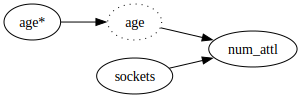

In [3]:
g = gr(graph_attr = {"rankdir": "LR"})
g.node("num_attl")
g.node("age", style="dotted")
g.node("age*")
g.node("sockets")
g.edge("age", "num_attl")
g.edge("sockets", "num_attl")
g.edge("age*", "age")
g

Import the data

In [4]:
filepath_str:str = "https://raw.githubusercontent.com/rmcelreath/stat_rethinking_2026/main/homework/amtl_homo_aggregated.csv"
df = pd.read_csv(filepath_str, sep=",")
df.head()

,specimen,age,stdev_age,num_amtl,sockets
0,NMNH227455,11.661009,1.268039,0,32
1,MH1503,15.567015,1.807743,1,32
2,MH4767,15.567015,1.807743,2,32
3,NMNH380448,15.784015,1.839889,0,32
4,UVS46,16.902650,1.892974,0,32


In [5]:
df.tail()

,specimen,age,stdev_age,num_amtl,sockets
305,NMNH225029,47.011596,21.358443,0,16
306,MH12326,50.164872,22.998910,6,16
307,MH12319,51.741511,23.819206,0,16
308,MH12322,59.624702,27.921159,1,16
309,MH12321,71.224255,31.416954,0,16


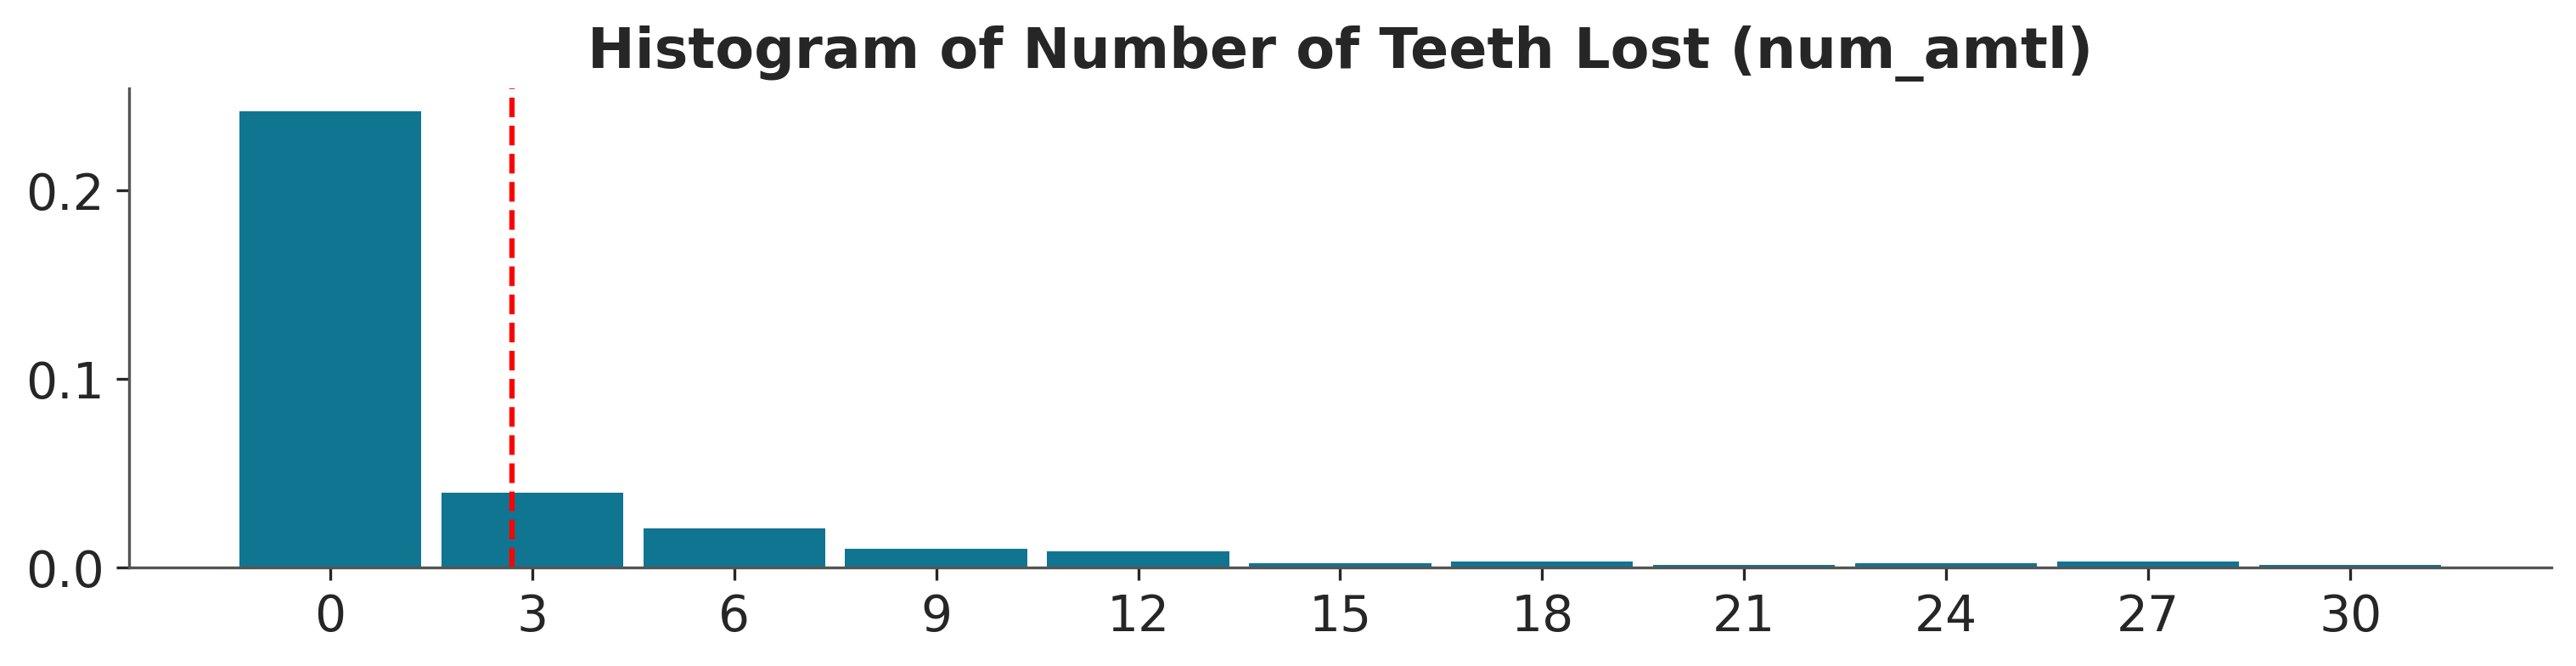

In [6]:
fig, ax = plt.subplots(figsize=(10, 2.5))
az.plot_dist(df["num_amtl"], ax=ax)
ax.axvline(df["num_amtl"].mean(), color="red", ls="--")
ax.set_title("Histogram of Number of Teeth Lost (num_amtl)")
plt.show()

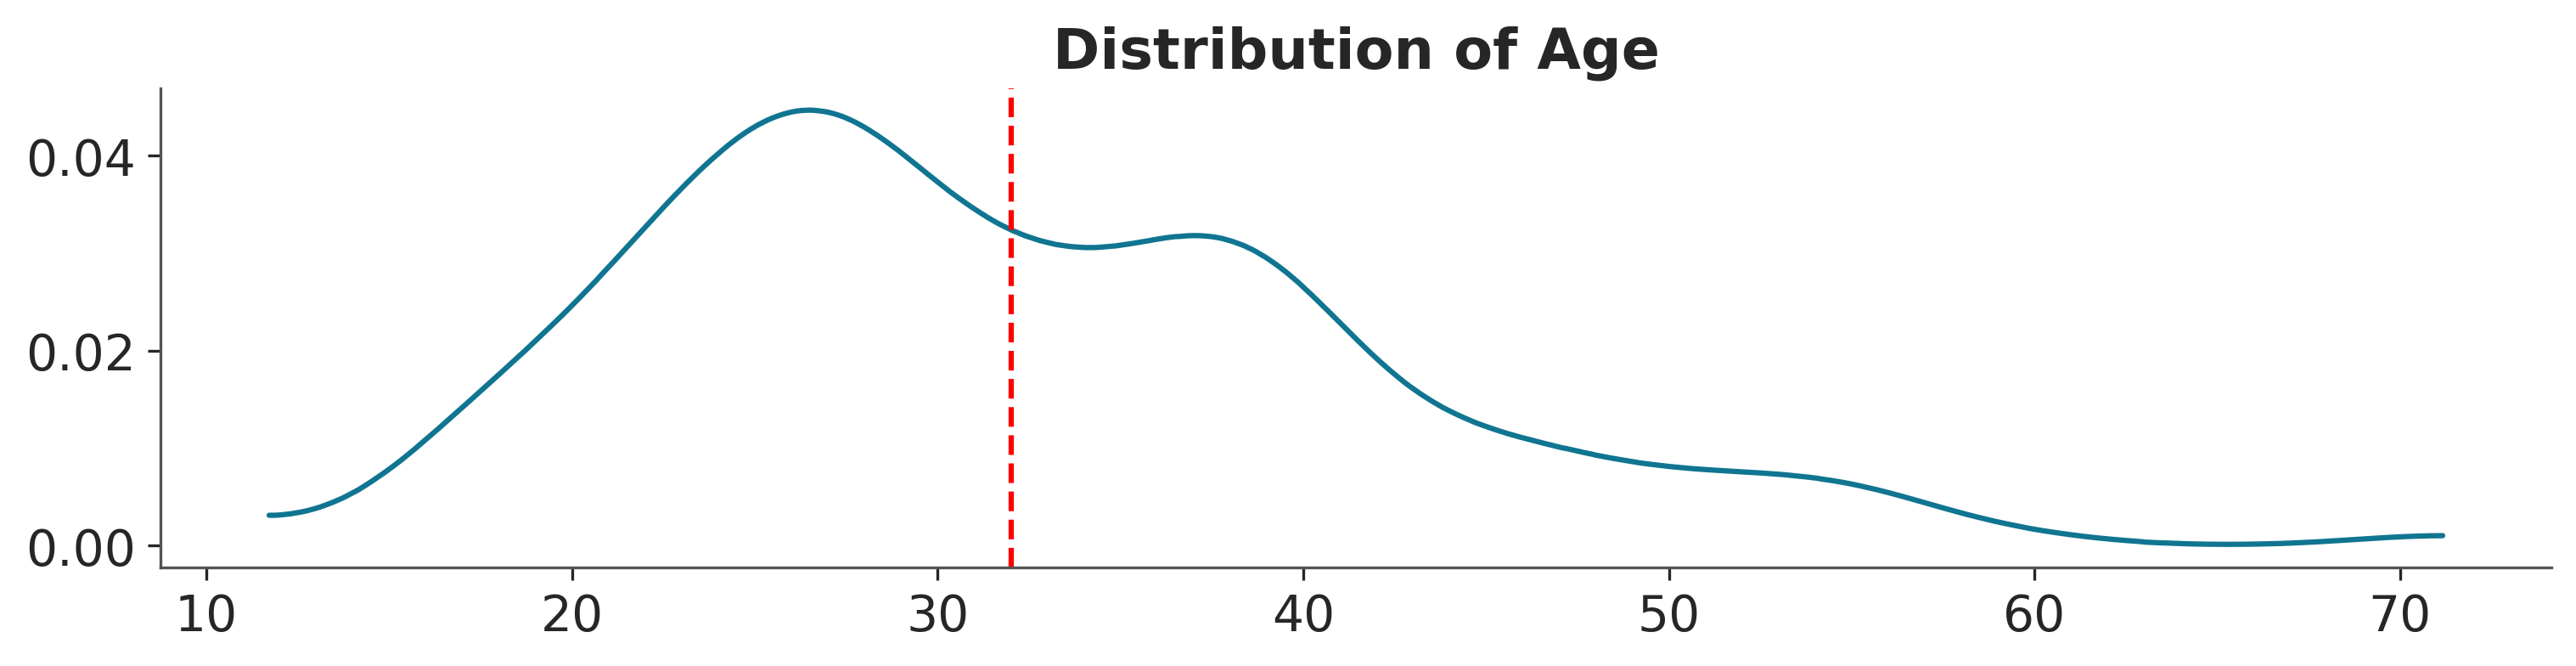

In [7]:
fig, ax = plt.subplots(figsize=(10, 2.5))
az.plot_dist(df["age"], ax=ax)
ax.axvline(df["age"].mean(), color="red", ls="--")
ax.set_title("Distribution of Age")
plt.show()

Begin Model 1: Let us use a poisson likelihood for count data and ignore measurement error

In [8]:
# Define
COORDS = {"obs": np.arange(len(df))}

with pm.Model(coords=COORDS) as hm_b07_no_error:

    # Mutable Data
    num_amtl = pm.Data("num_amtl", df["num_amtl"].values, dims="obs")
    s = pm.Data("s", df["sockets"].values, dims="obs")
    a = pm.Data("a", df["age"].values, dims="obs")

    # Priors
    α = pm.Normal("α", mu=0, sigma=1)
    β_s = pm.Normal("β_s", 0, 1)
    β_a = pm.Normal("β_a", 0, 1)

    # Mean
    μ = α + β_s * s + β_a * a

    # Likelihood
    counts = pm.Poisson("counts", pm.math.exp(μ), observed=num_amtl, dims="obs")

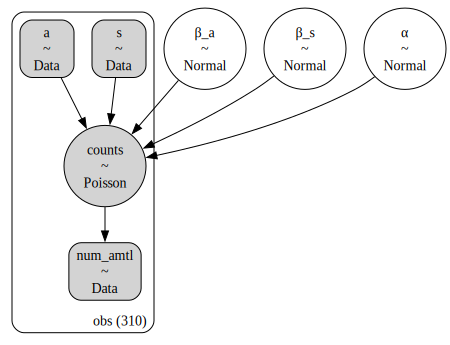

In [9]:
pm.model_to_graphviz(hm_b07_no_error)

In [10]:
with hm_b07_no_error:
    idata_no_error = pm.sample(random_seed=random_seed)
    idata_no_error.extend(
        pm.sample_posterior_predictive(
            idata_no_error,
            random_seed=random_seed
        )
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β_s, β_a]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
Sampling: [counts]


Output()

In [11]:
az.summary(idata_no_error, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,-2.49,0.23,-2.93,-2.07,0.01,0.0,1098.74,1420.68,1.0
β_s,0.05,0.01,0.04,0.06,0.00,0.0,1308.94,1718.10,1.0
β_a,0.06,0.00,0.05,0.07,0.00,0.0,1232.00,1281.18,1.0


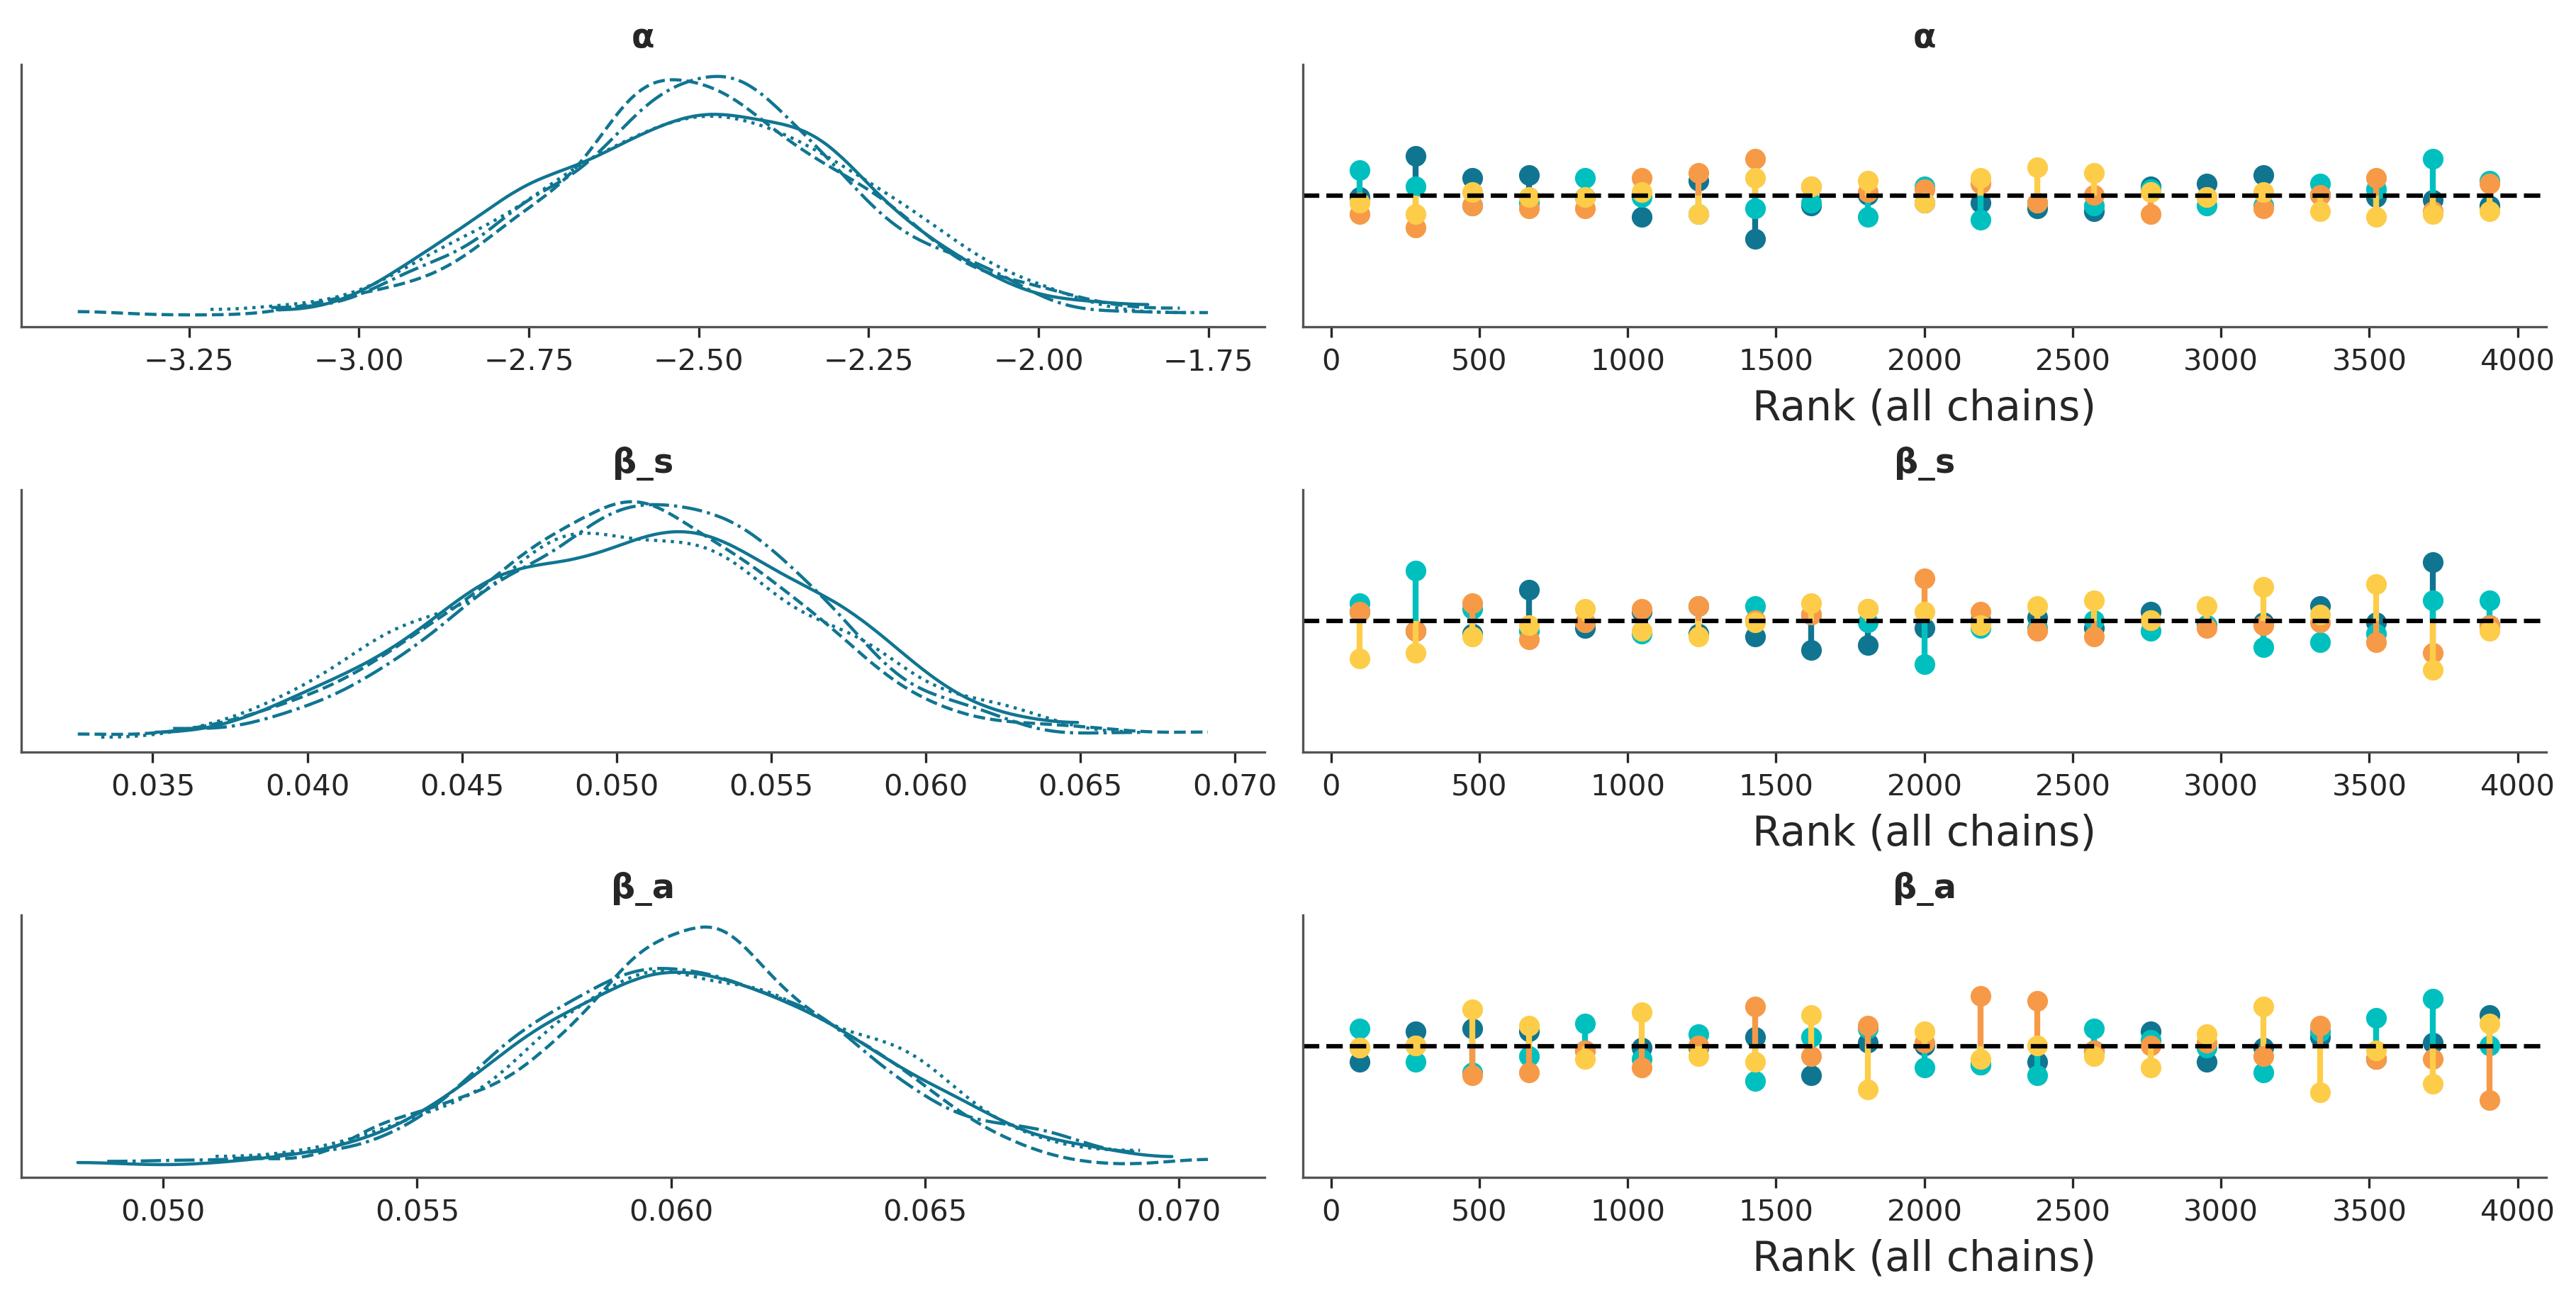

In [12]:
az.plot_trace(idata_no_error, kind="rank_vlines")
plt.show()

Now let us add the error for age

In [13]:
# Define
COORDS = {"obs": np.arange(len(df))}

with pm.Model(coords=COORDS) as hm_b07:

    # Mutable Data
    num_amtl = pm.Data("num_amtl", df["num_amtl"].values, dims="obs")
    s = pm.Data("s", df["sockets"].values, dims="obs")
    a_star = pm.Data("a_star", df["age"].values, dims="obs")
    age_std = pm.Data("age_std", df["stdev_age"].values, dims="obs")

    # Priors: mostly same priors
    α = pm.Normal("α", mu=0, sigma=2.)
    β_s = pm.Normal("β_s", 0, 1)
    β_a = pm.Normal("β_a", 0, 1)


    # True age: A mean given by a_star with std of age_std: Truncate at 0
    a = pm.TruncatedNormal("a", mu=a_star, sigma=age_std, lower=0, upper=100, dims="obs")

    # Mean
    μ = α + β_s * s + β_a * a

    # Likelihood
    likelihood = pm.Poisson("likelihood", mu=pm.math.exp(μ), dims="obs", observed=num_amtl)    

In [14]:
with hm_b07:
    idata = pm.sample(random_seed=random_seed)
    idata.extend(
        pm.sample_posterior_predictive(
            idata,
            random_seed=random_seed
        )
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β_s, β_a, a]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [likelihood]


Output()

In [15]:
az.summary(idata, var_names=["α", "β_s", "β_a"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,-5.97,0.58,-7.09,-4.92,0.02,0.01,623.45,1208.10,1.01
β_s,0.07,0.01,0.05,0.10,0.00,0.00,1571.15,2396.79,1.00
β_a,0.14,0.01,0.11,0.16,0.00,0.00,415.72,877.12,1.01


Let us look at what the model did to age* when accounting for error

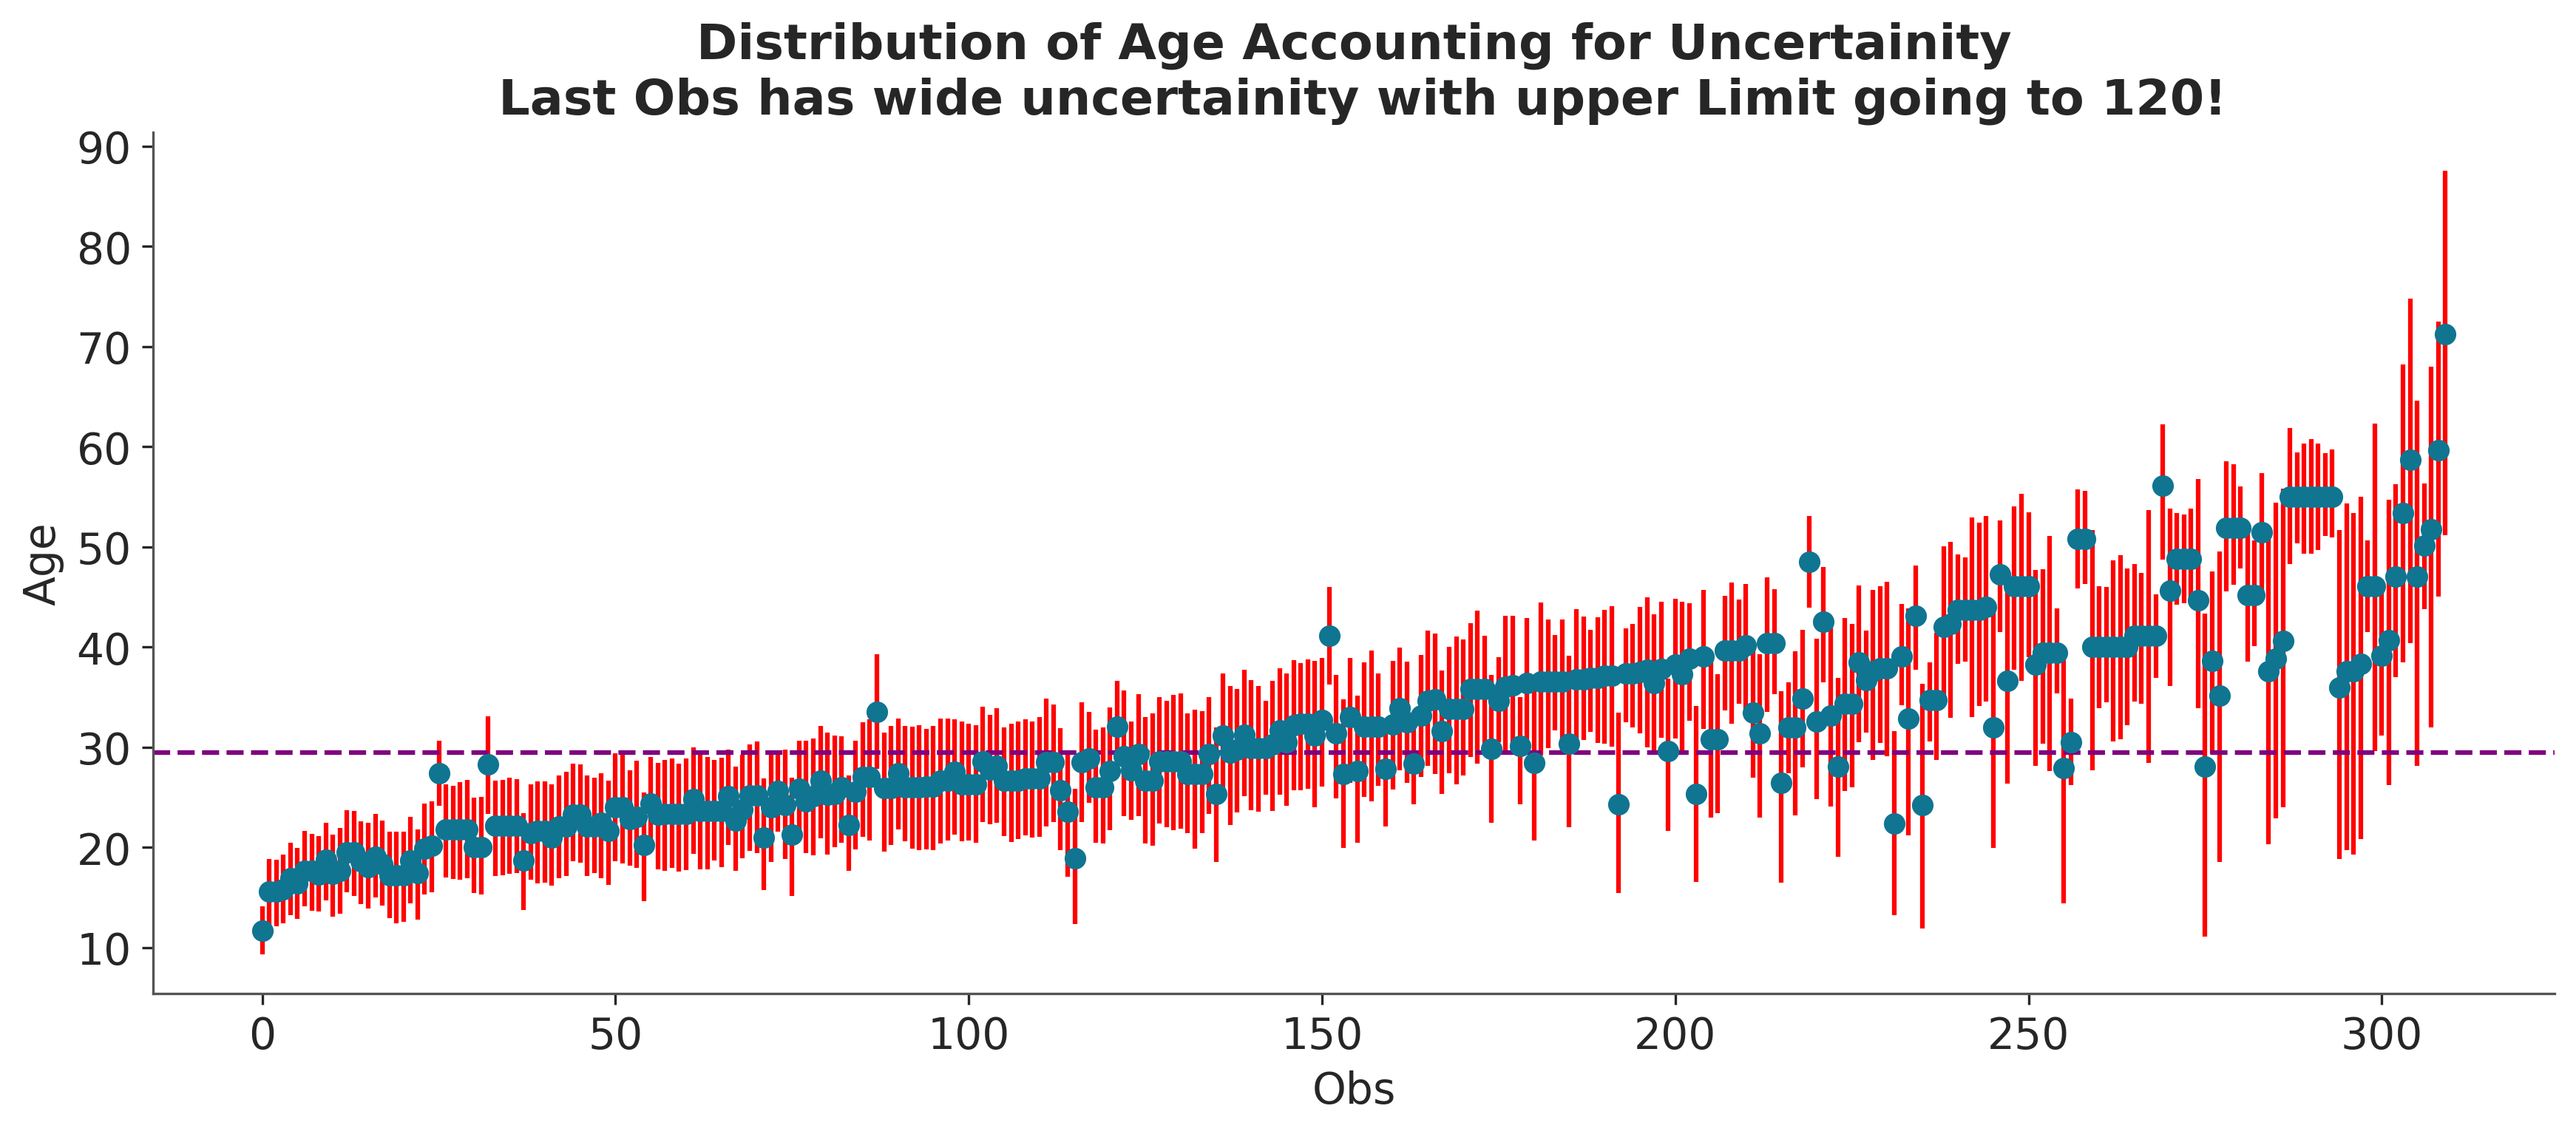

In [16]:
# 94% HDI interval:
a_hdi = az.hdi(idata.posterior["a"], input_core_dims=[["chain", "draw"]])["a"].to_numpy()
lower, upper = a_hdi[:, 0], a_hdi[:, 1]

# Mean value
a_mean = idata.posterior["a"].mean(dim=("chain", "draw")).to_numpy()

# Lower and upper bounds on age
lower_errors = a_mean - lower
upper_errors = upper - a_mean

fig, ax = plt.subplots()
ax.errorbar(np.arange(len(df)),
            df["age"].values,
            yerr=[lower_errors, upper_errors],
            fmt="o",
            ecolor="red"
           )
ax.axhline(np.mean(a_mean), color="purple", ls="--")
ax.set_xlabel("Obs")
ax.set_ylabel("Age")
ax.set_title("Distribution of Age Accounting for Uncertainity\n Last Obs has wide uncertainity with upper Limit going to 120!")
plt.show()

Compare mean amtl across the two models <br>
Note for a poisson process the mean is given by $\lambda$

In [17]:
# Not taking into account error
λ_no_error = np.exp(
    idata_no_error.posterior["α"].stack(sample=("chain", "draw")).values[:, None] +
    idata_no_error.posterior["β_s"].stack(sample=("chain", "draw")).values[:, None] * df["sockets"].values +
    idata_no_error.posterior["β_a"].stack(sample=("chain", "draw")).values[:, None] * df["age"].values
)

# Taking into account error
λ_error = np.exp(
    idata.posterior["α"].stack(sample=("chain", "draw")).values[:, None] +
    idata.posterior["β_s"].stack(sample=("chain", "draw")).values[:, None] * df["sockets"].values +
    idata.posterior["β_a"].stack(sample=("chain", "draw")).values[:, None] * 
    idata.posterior["a"].stack(sample=("chain", "draw")).values.T
)

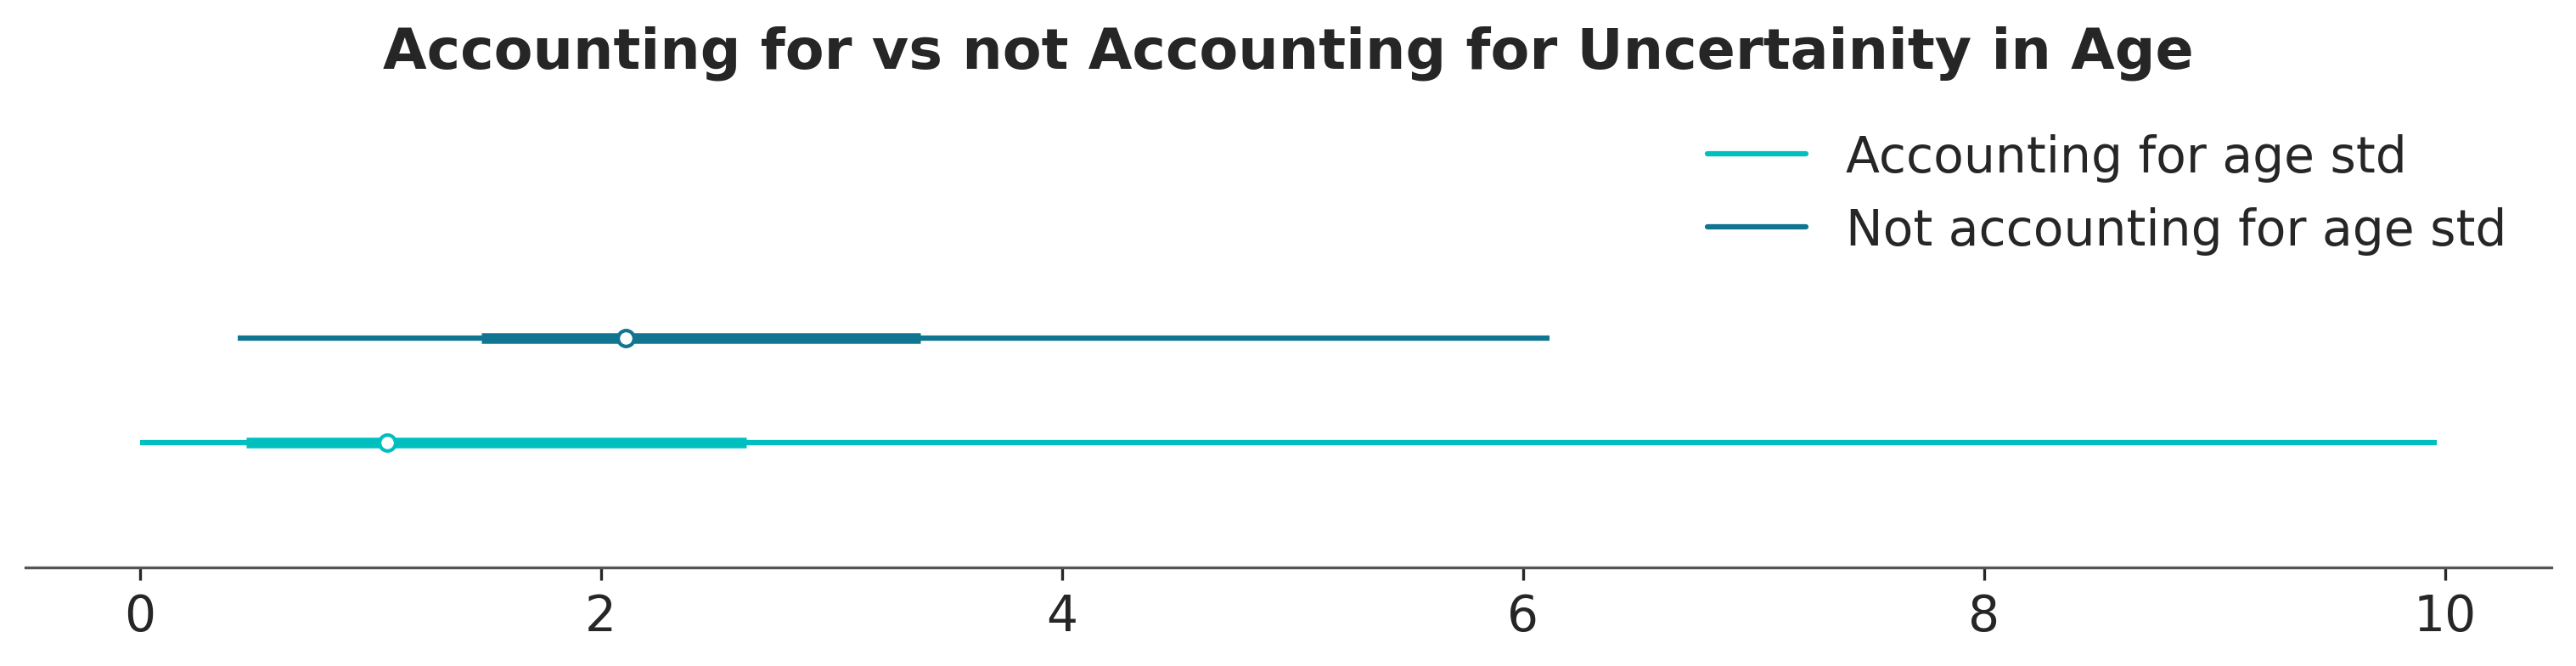

In [18]:
_, ax = plt.subplots(figsize=(10, 2.5))
az.plot_forest(
    [λ_no_error.reshape(4, 1_000*len(df)), λ_error.reshape(4, 1_000*len(df))],
    combined=True,
    kind="forestplot",
    model_names=["Not accounting for age std", "Accounting for age std"],
    ax=ax
)
ax.set_title("Accounting for vs not Accounting for Uncertainity in Age")
ax.set_yticklabels([])
plt.show()

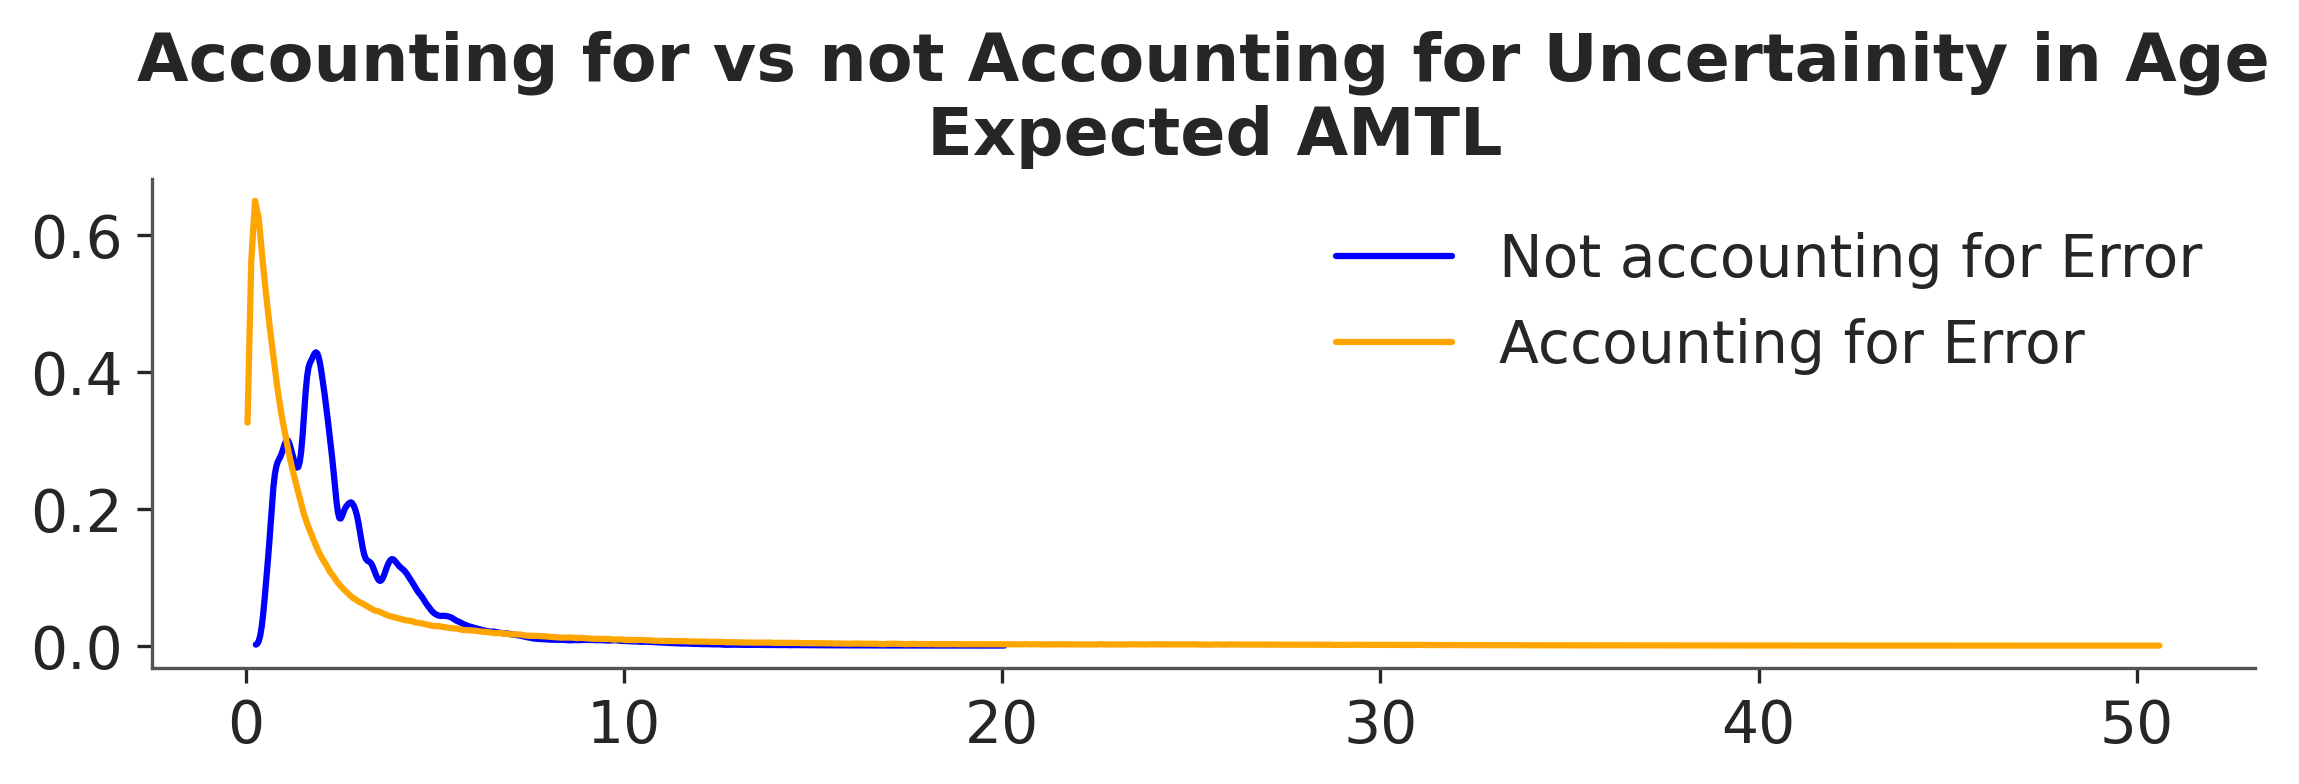

In [19]:
_, ax = plt.subplots(figsize=(7.5, 2.5))
az.plot_dist(
    λ_no_error,
    kind="kde",
    color="blue",
    label="Not accounting for Error",
    ax=ax
)
az.plot_dist(
    λ_error,
    kind="kde",
    color="orange",
    label="Accounting for Error",
    ax=ax
)
ax.set_title("Accounting for vs not Accounting for Uncertainity in Age\n Expected AMTL")
plt.show()

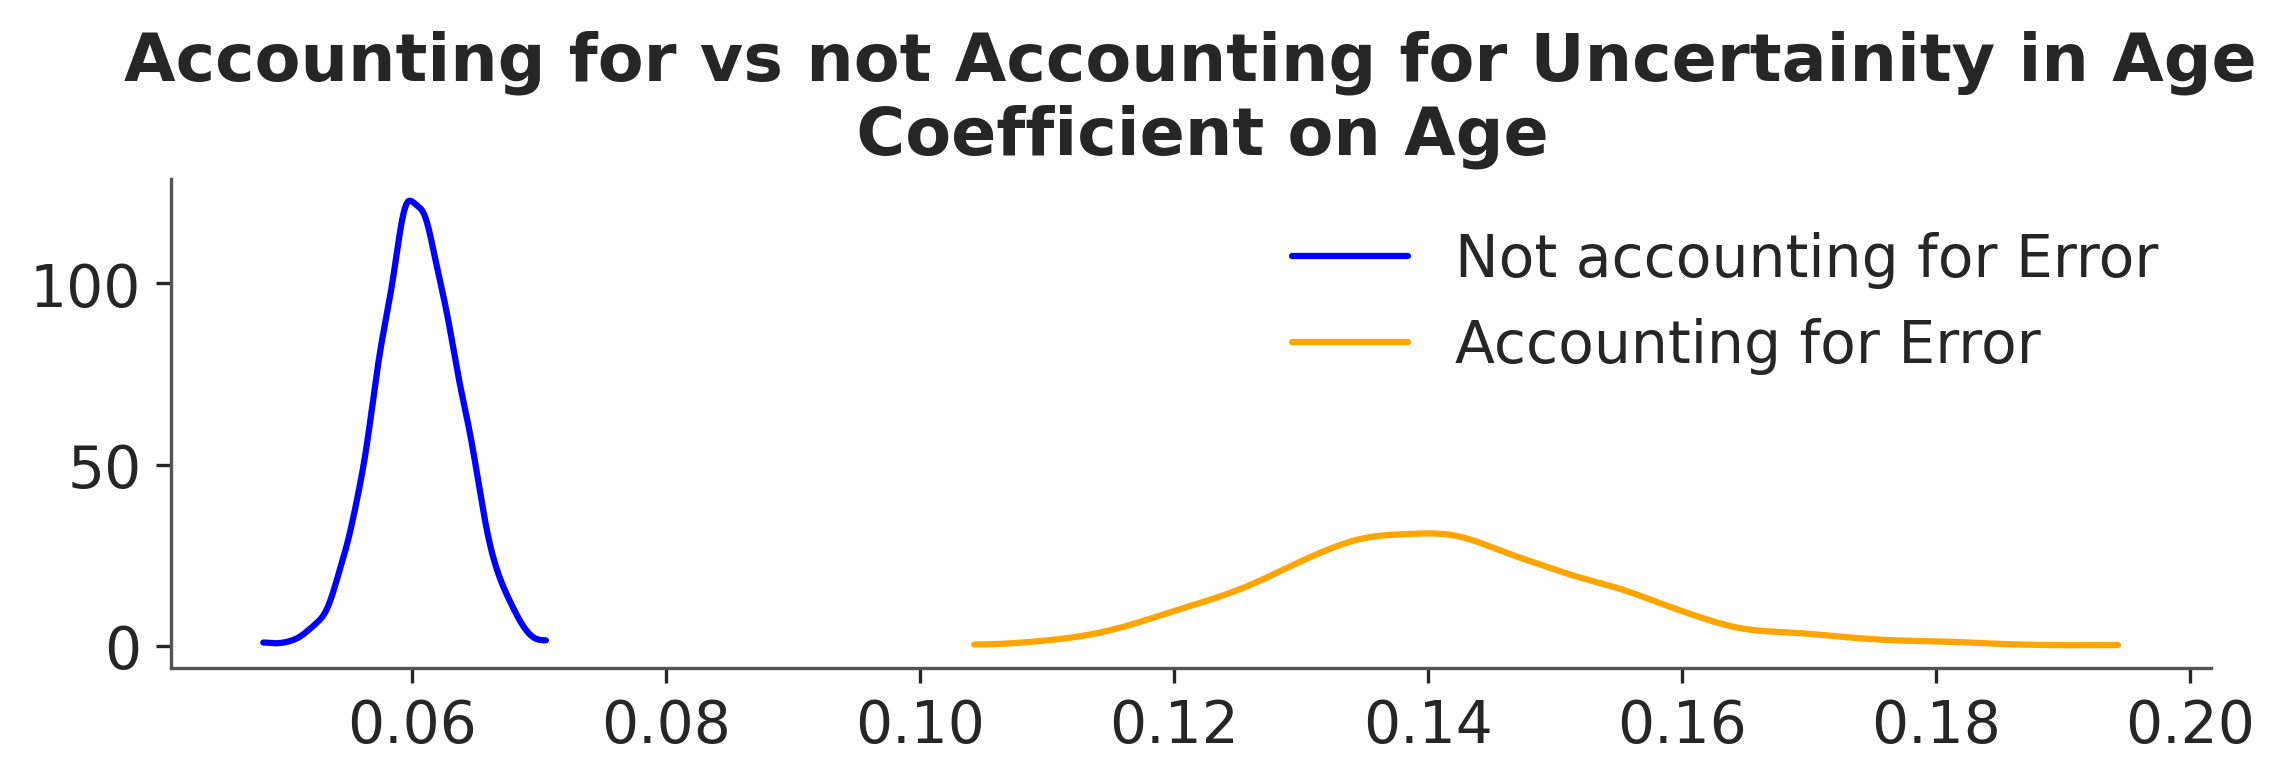

In [20]:
_, ax = plt.subplots(figsize=(7.5, 2.5))
az.plot_dist(
    idata_no_error.posterior["β_a"],
    kind="kde",
    color="blue",
    label="Not accounting for Error",
    ax=ax
)
az.plot_dist(
    idata.posterior["β_a"],
    kind="kde",
    color="orange",
    label="Accounting for Error",
    ax=ax
)
ax.set_title("Accounting for vs not Accounting for Uncertainity in Age\n Coefficient on Age")
plt.show()